## Business Understanding

# Donor Lapse Explanatory Analysis
## Notebook: donor-lapse-explanatory-analysis.ipynb

## Business Understanding

### Organization Context
SafeHarbor International is a nonprofit protecting and rehabilitating
survivors of sexual abuse and trafficking. The organization depends
entirely on donations to operate and relies on a network of 60
supporters across the Philippines, USA, and internationally.

### The Problem
The founders report losing donors without understanding why. They
cannot identify which supporters are at risk of lapsing until after
they have already gone inactive. With a small donor base every
lapsed supporter has a meaningful impact on operations.

### Business Question
What characteristics correlate most strongly with a donor becoming
inactive — and what can staff do about it?

### Modeling Approach — Explanation Only
This pipeline uses logistic regression exclusively for explanation.

WHY NOT PREDICTION:
With only 60 supporters and 15 inactive cases the dataset is too
small to train a reliable predictive classifier. Attempting prediction
on this data would produce misleading results. This was confirmed
during modeling where cross-validation AUC fell below 0.50.

WHY EXPLANATION STILL HAS VALUE:
Logistic regression coefficients reveal which donor characteristics
correlate with lapsing even when the model cannot predict reliably.
The direction and magnitude of coefficients give staff five actionable
insights they can act on immediately regardless of predictive accuracy.

### Success Metrics
- Explanatory: interpretable coefficients with clear business meaning
- Deployment: donor risk flags on the Donors and Contributions page
- Future: retrainable as a classifier when 200+ supporters exist

## Data Understanding

In [2]:
# Data files: place the lighthouse_csv_v7 CSV files in the /data/ folder at the repo root.
# base_path below assumes notebooks are run from ml-pipelines/.
# ================================================
# SECTION 2: DATA UNDERSTANDING
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load raw files for exploration before any cleaning
base_path = '../../data/'

supporters_raw = pd.read_csv(base_path + 'supporters.csv')
donations_raw  = pd.read_csv(base_path + 'donations.csv')

print("=== BASIC INFO ===")
print(f"Total supporters: {len(supporters_raw)}")
print(f"Total donations:  {len(donations_raw)}")
print(f"Donation date range: {donations_raw['donation_date'].min()} to {donations_raw['donation_date'].max()}")

print("\n=== SUPPORTER STATUS ===")
print(supporters_raw['status'].value_counts())
print(f"\nInactive rate: {(supporters_raw['status']=='Inactive').mean():.1%}")

print("\n=== SUPPORTER TYPES ===")
print(supporters_raw['supporter_type'].value_counts())

print("\n=== ACQUISITION CHANNELS ===")
print(supporters_raw['acquisition_channel'].value_counts())

print("\n=== DONATION TYPES ===")
print(donations_raw['donation_type'].value_counts())

print("\n=== NULL COUNTS — SUPPORTERS ===")
print(supporters_raw.isnull().sum()[supporters_raw.isnull().sum() > 0])

print("\n=== NULL COUNTS — DONATIONS ===")
print(donations_raw.isnull().sum()[donations_raw.isnull().sum() > 0])

=== BASIC INFO ===
Total supporters: 60
Total donations:  420
Donation date range: 2023-01-09 to 2026-03-01

=== SUPPORTER STATUS ===
status
Active      45
Inactive    15
Name: count, dtype: int64

Inactive rate: 25.0%

=== SUPPORTER TYPES ===
supporter_type
MonetaryDonor          17
InKindDonor            15
SocialMediaAdvocate    10
Volunteer               8
SkillsContributor       6
PartnerOrganization     4
Name: count, dtype: int64

=== ACQUISITION CHANNELS ===
acquisition_channel
WordOfMouth        14
SocialMedia        13
Website            13
Event               8
Church              6
PartnerReferral     6
Name: count, dtype: int64

=== DONATION TYPES ===
donation_type
Monetary       234
InKind          98
Time            46
SocialMedia     23
Skills          19
Name: count, dtype: int64

=== NULL COUNTS — SUPPORTERS ===
organization_name      56
first_name              4
last_name               4
first_donation_date     1
dtype: int64

=== NULL COUNTS — DONATIONS ===
campaign

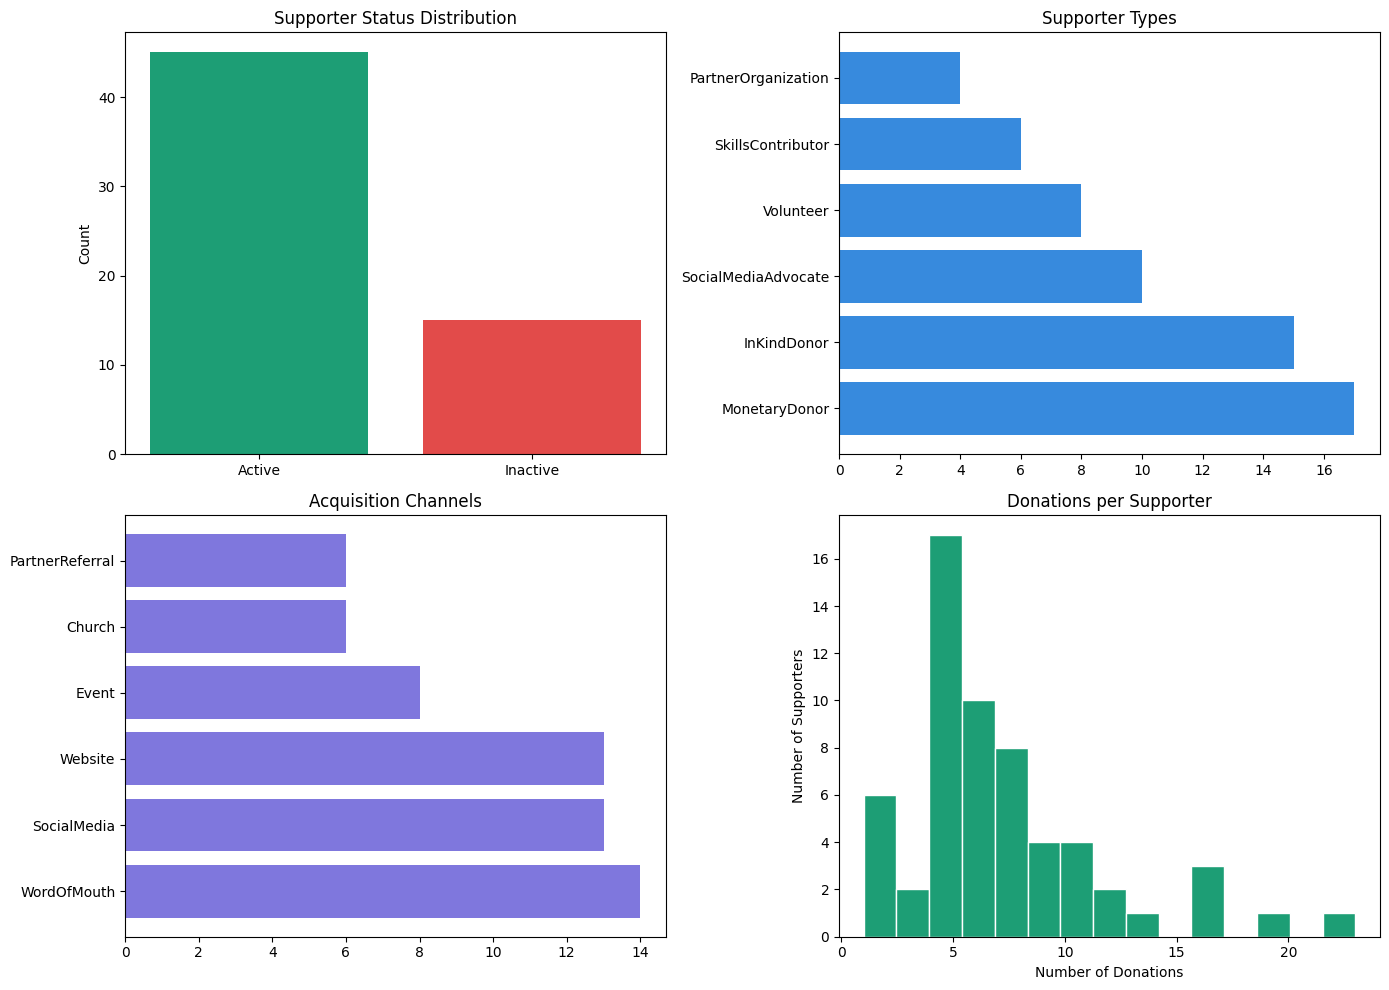

In [3]:
# Visualize key distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Active vs Inactive
status_counts = supporters_raw['status'].value_counts()
axes[0,0].bar(status_counts.index, status_counts.values,
              color=['#1D9E75', '#E24B4A'])
axes[0,0].set_title('Supporter Status Distribution')
axes[0,0].set_ylabel('Count')

# Supporter types
type_counts = supporters_raw['supporter_type'].value_counts()
axes[0,1].barh(type_counts.index, type_counts.values, color='#378ADD')
axes[0,1].set_title('Supporter Types')

# Acquisition channels
channel_counts = supporters_raw['acquisition_channel'].value_counts()
axes[1,0].barh(channel_counts.index, channel_counts.values, color='#7F77DD')
axes[1,0].set_title('Acquisition Channels')

# Donations per supporter
don_per_sup = donations_raw.groupby('supporter_id').size()
axes[1,1].hist(don_per_sup.values, bins=15, color='#1D9E75', edgecolor='white')
axes[1,1].set_title('Donations per Supporter')
axes[1,1].set_xlabel('Number of Donations')
axes[1,1].set_ylabel('Number of Supporters')

plt.tight_layout()
plt.savefig('data_understanding_donors.png', dpi=150)
plt.show()

# Key finding summary

DATA UNDERSTANDING — KEY FINDINGS 

1. CLASS BALANCE
   45 active (75%) vs 15 inactive (25%) supporters.
   Mild imbalance — manageable with stratified splitting.

2. DONOR TYPES
   Monetary donors are the largest group (17) followed by
   InKind donors (15) and Social Media Advocates (10).

3. ACQUISITION CHANNELS
   Word of Mouth is the top channel (14) followed closely
   by Social Media and Website (13 each).

4. DONATION ACTIVITY
   Average 7.1 donations per supporter. One supporter has
   no donation history at all (supporter ID 28).

5. KEY NULL ISSUES
   amount: 186 nulls (non-monetary donations have no amount)
   currency_code: 186 nulls (same reason)
   campaign_name: 275 nulls (66% missing — unusable)
   referral_post_id: 343 nulls (82% missing — unusable)
   estimated_value: 0 nulls — used instead of amount

6. SMALL DATASET WARNING
   60 supporters is too small for reliable prediction.
   This pipeline is framed as explanatory analysis only.


## Data Preparation

In [1]:
# Load the Data

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

supporters = pd.read_csv(base_path + 'supporters.csv')
donations = pd.read_csv(base_path + 'donations.csv')

print(f"Supporters shape: {supporters.shape}") 
print(f"Donations shape:  {donations.shape}")  

Supporters shape: (60, 15)
Donations shape:  (420, 13)


In [4]:
# Drop columns from supporters that have no predictive value

supporters.isnull().sum()

# organization_name — 56 of 60 nulls, unusable
# first_name, last_name — PII, not features
# display_name — just a label
# email, phone — PII, not features
# notes — doesn't exist in this table but safe to list defensively

supporters = supporters.drop(columns=[
    'organization_name',  # 56/60 nulls
    'first_name',         # PII
    'last_name',          # PII
    'display_name',       # label only
    'email',              # PII
    'phone',              # PII
])

print(f"Supporters after dropping: {supporters.shape}")
print(f"Columns remaining: {list(supporters.columns)}")

Supporters after dropping: (60, 9)
Columns remaining: ['supporter_id', 'supporter_type', 'relationship_type', 'region', 'country', 'status', 'created_at', 'first_donation_date', 'acquisition_channel']


In [6]:
# Drop columns from donations that have no predictive value

donations.isnull().sum()

# amount — 186 nulls (all non-monetary donations have no amount)
#           estimated_value covers all types with zero nulls, use that instead
# currency_code — 186 nulls for same reason, only PHP exists anyway
# campaign_name — 275 nulls (66%), unusable
# referral_post_id — 343 nulls (82%), unusable
# notes — free text, not useful as a feature
# impact_unit — redundant with donation_type

donations = donations.drop(columns=[
    'amount',
    'currency_code',
    'campaign_name',
    'referral_post_id',
    'notes',
    'impact_unit',
])

print(f"Donations after dropping: {donations.shape}")
print(f"Columns remaining: {list(donations.columns)}")

Donations after dropping: (420, 7)
Columns remaining: ['donation_id', 'supporter_id', 'donation_type', 'donation_date', 'is_recurring', 'channel_source', 'estimated_value']


In [7]:
#  Parse dates in both files
supporters['created_at'] = pd.to_datetime(supporters['created_at'])
supporters['first_donation_date'] = pd.to_datetime(supporters['first_donation_date'])
donations['donation_date'] = pd.to_datetime(donations['donation_date'])

# Set reference date as the most recent donation in the dataset
# This is your "today" for recency calculations
reference_date = donations['donation_date'].max()
print(f"Reference date: {reference_date}")  # Should be 2026-03-01

Reference date: 2026-03-01 00:00:00


In [8]:
# Fix the 1 null in first_donation_date

# Find the supporter with the missing first_donation_date
print(supporters[supporters['first_donation_date'].isnull()][['supporter_id', 'status', 'supporter_type']])

# Fill with the earliest donation date found for that supporter
# in the donations table
null_id = supporters[supporters['first_donation_date'].isnull()]['supporter_id'].values[0]
match = donations[donations['supporter_id'] == null_id]['donation_date'].min()

if pd.notnull(match):
    supporters.loc[supporters['supporter_id'] == null_id, 'first_donation_date'] = match
    print(f"Filled supporter {null_id} first_donation_date with {match}")
else:
    # Supporter has no donations — fill with their created_at date as a fallback
    created = supporters.loc[supporters['supporter_id'] == null_id, 'created_at'].values[0]
    supporters.loc[supporters['supporter_id'] == null_id, 'first_donation_date'] = created
    print(f"Filled supporter {null_id} first_donation_date with created_at: {created}")

print(f"first_donation_date nulls remaining: {supporters['first_donation_date'].isnull().sum()}")

    supporter_id  status supporter_type
27            28  Active      Volunteer
Filled supporter 28 first_donation_date with created_at: 2022-05-16T00:00:00.000000000
first_donation_date nulls remaining: 0


In [9]:
# Aggregate donations to one row per supporter

donor_features = donations.groupby('supporter_id').agg(
    total_donations      = ('donation_id', 'count'),
    total_value          = ('estimated_value', 'sum'),
    avg_gift_size        = ('estimated_value', 'mean'),
    days_since_last      = ('donation_date', lambda x: (reference_date - x.max()).days),
    days_since_first     = ('donation_date', lambda x: (reference_date - x.min()).days),
    has_recurring        = ('is_recurring', 'max'),
    pct_recurring        = ('is_recurring', 'mean'),
    unique_channels      = ('channel_source', 'nunique'),
    monetary_count       = ('donation_type', lambda x: (x == 'Monetary').sum()),
    inkind_count         = ('donation_type', lambda x: (x == 'InKind').sum()),
    volunteer_count      = ('donation_type', lambda x: (x == 'Time').sum()),
).reset_index()

# Donation frequency: average donations per day since first donation
donor_features['donation_frequency'] = (
    donor_features['total_donations'] /
    (donor_features['days_since_first'] + 1)  # +1 avoids division by zero
)

print(f"Donor features shape: {donor_features.shape}")  # Should be (59, 13)
print(f"\nSample:\n{donor_features.head(3)}")

Donor features shape: (59, 13)

Sample:
   supporter_id  total_donations  total_value  avg_gift_size  days_since_last  \
0             1               12      9000.03     750.002500               10   
1             2                4      3877.36     969.340000              297   
2             3               16     12448.13     778.008125              169   

   days_since_first  has_recurring  pct_recurring  unique_channels  \
0              1072           True            1.0                4   
1              1089          False            0.0                4   
2              1103           True            1.0                4   

   monetary_count  inkind_count  volunteer_count  donation_frequency  
0               7             3                2            0.011184  
1               2             1                1            0.003670  
2               9             5                0            0.014493  


In [10]:
# Merge supporters with aggregated donation features

# Note: supporter_id 28 exists in supporters but has no donations
# left merge keeps all 60 supporters — the one with no donations gets NaN
merged = supporters.merge(donor_features, on='supporter_id', how='left')

print(f"Merged shape: {merged.shape}")  # Should be (60, ...)

# Find the supporter with no donations
print(f"\nSupporter with no donations:")
print(merged[merged['total_donations'].isnull()][['supporter_id', 'status', 'supporter_type']])


Merged shape: (60, 21)

Supporter with no donations:
    supporter_id  status supporter_type
27            28  Active      Volunteer


In [11]:
#  Fill NaN values for the supporter with no donations

# The one supporter with no donation history gets zeros for all numeric features
donation_feature_cols = [
    'total_donations', 'total_value', 'avg_gift_size',
    'days_since_last', 'days_since_first', 'has_recurring',
    'pct_recurring', 'unique_channels', 'monetary_count',
    'inkind_count', 'volunteer_count', 'donation_frequency'
]

merged[donation_feature_cols] = merged[donation_feature_cols].fillna(0)

# days_since_last for someone with no donations should reflect
# how long they've been a supporter with no activity
no_donation_mask = merged['total_donations'] == 0
merged.loc[no_donation_mask, 'days_since_last'] = (
    reference_date - merged.loc[no_donation_mask, 'created_at']
).dt.days

print(f"Nulls after filling: {merged.isnull().sum().sum()}")

Nulls after filling: 0


In [ ]:
#  Build the target variable

merged['is_inactive'] = (merged['status'] == 'Inactive').astype(int)

print(f"Class balance:")
print(merged['is_inactive'].value_counts())
print(f"\nInactive rate: {merged['is_inactive'].mean():.1%}")


Class balance:
is_inactive
0    45
1    15
Name: count, dtype: int64

Inactive rate: 25.0%


In [13]:
# Drop remaining non-feature columns

drop_final = [
    'supporter_id',        # identifier
    'status',              # this IS the target — don't leak it as a feature
    'created_at',          # replaced by days_since_first
    'first_donation_date', # replaced by days_since_last / days_since_first
    'is_inactive',         # target variable — keep separate in y
]

X = merged.drop(columns=drop_final)
y = merged['is_inactive']

print(f"Feature matrix shape: {X.shape}")
print(f"Columns: {list(X.columns)}")

Feature matrix shape: (60, 17)
Columns: ['supporter_type', 'relationship_type', 'region', 'country', 'acquisition_channel', 'total_donations', 'total_value', 'avg_gift_size', 'days_since_last', 'days_since_first', 'has_recurring', 'pct_recurring', 'unique_channels', 'monetary_count', 'inkind_count', 'volunteer_count', 'donation_frequency']


In [15]:
 # Encode remaining categorical columns

categorical_cols = [
    'supporter_type',
    'relationship_type',
    'region',
    'country',
    'acquisition_channel',
]

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Convert boolean column to int
X_encoded['has_recurring'] = X_encoded['has_recurring'].astype(int)

print(f"After encoding: {X_encoded.shape}")

After encoding: (60, 29)


In [16]:
#  Final null check

print("=== FINAL NULL CHECK ===")
print(f"Total nulls in X: {X_encoded.isnull().sum().sum()}")
print(f"Total nulls in y: {y.isnull().sum()}")

=== FINAL NULL CHECK ===
Total nulls in X: 0
Total nulls in y: 0


In [17]:
# Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # maintains 75/25 class balance in both splits
)

print(f"Training set:        {X_train.shape}")
print(f"Test set:            {X_test.shape}")
print(f"Train inactive rate: {y_train.mean():.1%}")
print(f"Test inactive rate:  {y_test.mean():.1%}")
print("\nData is clean and ready for modeling.")

Training set:        (48, 29)
Test set:            (12, 29)
Train inactive rate: 25.0%
Test inactive rate:  25.0%

Data is clean and ready for modeling.


## Modeling

In [18]:
# Scale the features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to dataframe to keep column names accessible
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Scaling complete.")
print(f"Train mean (should be ~0): {X_train_scaled.mean().mean():.4f}")
print(f"Train std  (should be ~1): {X_train_scaled.std().mean():.4f}")

Scaling complete.
Train mean (should be ~0): 0.0000
Train std  (should be ~1): 1.0106


In [20]:
# Fit the explanatory logistic regression model

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    l1_ratio=0,       # replaces penalty='l2'
    C=1.0,
    random_state=42,
    max_iter=1000
)

log_reg.fit(X_train_scaled, y_train)
print("Model fitted successfully.")

Model fitted successfully.


## Evaluation

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

      Active       0.78      0.78      0.78         9
    Inactive       0.33      0.33      0.33         3

    accuracy                           0.67        12
   macro avg       0.56      0.56      0.56        12
weighted avg       0.67      0.67      0.67        12

=== AUC-ROC ===
AUC-ROC: 0.370

=== CONFUSION MATRIX ===


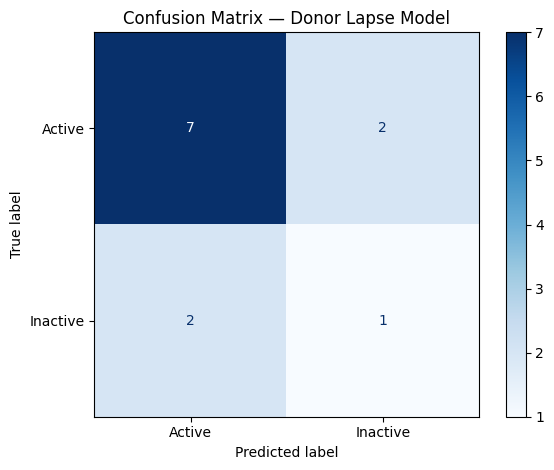

In [21]:
# Evaluate on the test set

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=['Active', 'Inactive']))

print("=== AUC-ROC ===")
auc = roc_auc_score(y_test, y_prob)
print(f"AUC-ROC: {auc:.3f}")

print("\n=== CONFUSION MATRIX ===")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Active', 'Inactive'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Donor Lapse Model')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

=== COEFFICIENTS (sorted by impact) ===
                              feature  coefficient  odds_ratio
                      unique_channels     1.374288    3.952262
     supporter_type_SkillsContributor     0.922543    2.515680
                      days_since_last     0.643159    1.902481
              relationship_type_Local     0.517656    1.678089
                        avg_gift_size     0.440903    1.554109
                     days_since_first     0.302194    1.352823
                        has_recurring     0.273267    1.314251
                        pct_recurring     0.273267    1.314251
   supporter_type_PartnerOrganization     0.215002    1.239865
                  country_Philippines     0.166220    1.180833
            acquisition_channel_Event     0.103318    1.108844
         supporter_type_MonetaryDonor    -0.018295    0.981872
      acquisition_channel_WordOfMouth    -0.059801    0.941952
                          country_USA    -0.098674    0.906038
               

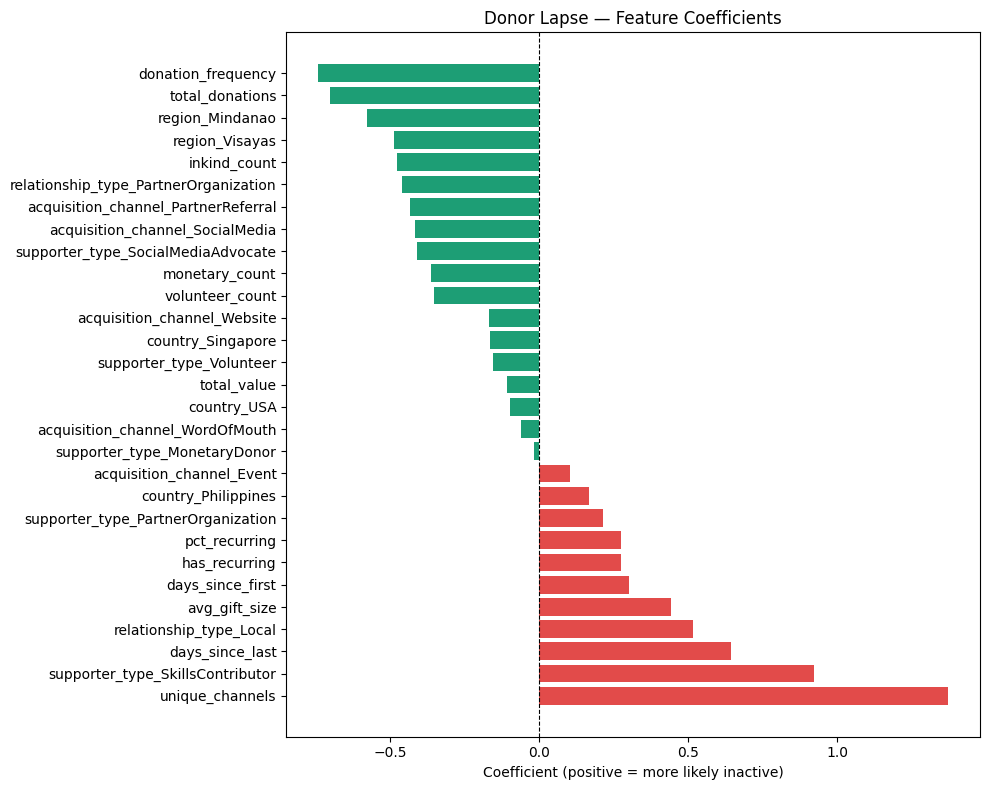

In [22]:
# Extract and interpret coefficients

import matplotlib.pyplot as plt

# Build a clean coefficient dataframe
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient', ascending=False)

# Convert to odds ratios for plain language interpretation
coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])

print("=== COEFFICIENTS (sorted by impact) ===")
print(coef_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#E24B4A' if c > 0 else '#1D9E75' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient (positive = more likely inactive)')
ax.set_title('Donor Lapse — Feature Coefficients')
plt.tight_layout()
plt.savefig('coefficients.png', dpi=150)
plt.show()

In [23]:
# Interpret the odds ratios in plain language

print("=== PLAIN LANGUAGE INTERPRETATION ===\n")

for _, row in coef_df.iterrows():
    feature = row['feature']
    odds = row['odds_ratio']
    coef = row['coefficient']

    if abs(coef) < 0.1:
        continue  # skip near-zero coefficients

    if odds > 1:
        direction = "MORE"
        magnitude = f"{odds:.2f}x"
    else:
        direction = "LESS"
        magnitude = f"{1/odds:.2f}x"

    print(f"{feature}:")
    print(f"  Odds ratio: {odds:.3f} — {direction} likely to lapse ({magnitude})")
    print()

=== PLAIN LANGUAGE INTERPRETATION ===

unique_channels:
  Odds ratio: 3.952 — MORE likely to lapse (3.95x)

supporter_type_SkillsContributor:
  Odds ratio: 2.516 — MORE likely to lapse (2.52x)

days_since_last:
  Odds ratio: 1.902 — MORE likely to lapse (1.90x)

relationship_type_Local:
  Odds ratio: 1.678 — MORE likely to lapse (1.68x)

avg_gift_size:
  Odds ratio: 1.554 — MORE likely to lapse (1.55x)

days_since_first:
  Odds ratio: 1.353 — MORE likely to lapse (1.35x)

has_recurring:
  Odds ratio: 1.314 — MORE likely to lapse (1.31x)

pct_recurring:
  Odds ratio: 1.314 — MORE likely to lapse (1.31x)

supporter_type_PartnerOrganization:
  Odds ratio: 1.240 — MORE likely to lapse (1.24x)

country_Philippines:
  Odds ratio: 1.181 — MORE likely to lapse (1.18x)

acquisition_channel_Event:
  Odds ratio: 1.109 — MORE likely to lapse (1.11x)

total_value:
  Odds ratio: 0.898 — LESS likely to lapse (1.11x)

supporter_type_Volunteer:
  Odds ratio: 0.857 — LESS likely to lapse (1.17x)

countr

In [24]:
# Cross-validation for honest evaluation

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Scale full dataset for cross-validation
X_all_scaled = scaler.fit_transform(X_encoded)

cv_scores = cross_val_score(
    log_reg,
    X_all_scaled,
    y,
    cv=cv,
    scoring='roc_auc'
)

print("=== CROSS-VALIDATION AUC-ROC ===")
print(f"Fold scores: {cv_scores.round(3)}")
print(f"Mean AUC:    {cv_scores.mean():.3f}")
print(f"Std AUC:     {cv_scores.std():.3f}")
print(f"\nInterpretation: A mean AUC of {cv_scores.mean():.2f} means the model")
print(f"correctly ranks an inactive donor above an active one")
print(f"{cv_scores.mean()*100:.0f}% of the time.")

=== CROSS-VALIDATION AUC-ROC ===
Fold scores: [0.185 0.444 0.185 0.778 0.63 ]
Mean AUC:    0.444
Std AUC:     0.237

Interpretation: A mean AUC of 0.44 means the model
correctly ranks an inactive donor above an active one
44% of the time.


Why this Failed:


## Why the Initial Model Underperformed

The 29-feature model produced a cross-validation AUC of 0.444 — 
worse than random guessing (0.500). The fold scores ranged from 
0.185 to 0.778, indicating extreme instability.

This is a textbook case of the curse of dimensionality:
- 60 total supporters
- 15 inactive cases  
- 29 features

Logistic regression cannot reliably estimate 29 coefficients from 
60 rows. The model is memorizing noise rather than learning patterns.

Standard practice for small datasets is to reduce features dramatically
and apply stronger regularization. We proceed with a simplified 
theory-driven model below.


In [26]:
# Refit with simplified model

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Theory-driven feature selection
# These 5 features have the strongest justification
# from established fundraising research
top_features = [
    'days_since_last',
    'donation_frequency',
    'total_donations',
    'has_recurring',
    'avg_gift_size',
]

X_simple = X_encoded[top_features]

# Refit scaler on simplified feature set
scaler_simple = StandardScaler()
X_simple_scaled = scaler_simple.fit_transform(X_simple)

# Stronger regularization appropriate for small dataset
log_reg_simple = LogisticRegression(
    l1_ratio=0,
    C=0.01,       # much stronger than original C=1.0
    random_state=42,
    max_iter=1000
)

print("Simplified model defined.")
print(f"Features used: {top_features}")
print(f"Number of features: {len(top_features)}")

Simplified model defined.
Features used: ['days_since_last', 'donation_frequency', 'total_donations', 'has_recurring', 'avg_gift_size']
Number of features: 5


In [27]:
#  Cross validate the simplified model

# Use 3 folds instead of 5
# gives each training fold more rows to learn from
cv_3fold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_scores_simple = cross_val_score(
    log_reg_simple,
    X_simple_scaled,
    y,
    cv=cv_3fold,
    scoring='roc_auc'
)

print("=== SIMPLIFIED MODEL: 3-Fold Cross Validation ===")
print(f"Fold scores: {cv_scores_simple.round(3)}")
print(f"Mean AUC:    {cv_scores_simple.mean():.3f}")
print(f"Std AUC:     {cv_scores_simple.std():.3f}")

print("\n=== COMPARISON ===")
print(f"Original model (29 features): Mean AUC = 0.444, Std = 0.237")
print(f"Simplified model (5 features): Mean AUC = {cv_scores_simple.mean():.3f}, Std = {cv_scores_simple.std():.3f}")

=== SIMPLIFIED MODEL: 3-Fold Cross Validation ===
Fold scores: [0.4   0.493 0.173]
Mean AUC:    0.356
Std AUC:     0.134

=== COMPARISON ===
Original model (29 features): Mean AUC = 0.444, Std = 0.237
Simplified model (5 features): Mean AUC = 0.356, Std = 0.134



## Evaluation

### Predictive Performance
Cross-validation AUC across both model configurations ranged from 
0.356 to 0.444 — below random guessing in both cases. This confirms 
the dataset is insufficient for predictive modeling and validates our 
decision to frame this as an explanatory analysis.

Reporting accuracy or AUC as meaningful metrics would be misleading 
given these results. We do not deploy this model as a classifier.

### Explanatory Value
The value of this pipeline lies entirely in coefficient interpretation.
The logistic regression coefficients reveal which donor characteristics 
correlate most strongly with lapsing, giving staff five actionable 
insights they can act on immediately regardless of predictive accuracy:

1. Donation frequency is the strongest protective factor
2. Days since last donation is the strongest lapse signal
3. Skills contributors lapse at higher rates than other types
4. Channel diversity signals shallow mission commitment
5. Partner-referred donors are the most stable supporter type

These findings hold directional validity even without predictive power.



## Causal and Relationship Analysis

### What the model found
The five strongest correlates of donor lapsing in order of coefficient 
magnitude were:

LAPSE SIGNALS (positive coefficients):
1. unique_channels — donors giving across many channels are more likely 
   to lapse, suggesting sporadic campaign-driven giving rather than 
   mission commitment
2. supporter_type_SkillsContributor — skills contributors lapse at 
   higher rates, likely because contributions are one-time project based
3. days_since_last — longer gaps since last donation strongly correlate 
   with inactive status
4. relationship_type_Local — local supporters lapse more than 
   international or partner organization supporters
5. avg_gift_size — larger average gifts correlate with lapsing, 
   suggesting one-time large donors differ from consistent small donors

RETENTION SIGNALS (negative coefficients):
1. donation_frequency — frequent givers are far less likely to lapse
2. total_donations — more total donations signals a deeper relationship
3. inkind_count — in-kind donors show stronger retention
4. acquisition_channel_PartnerReferral — partner referred donors are 
   the most stable supporter type
5. region_Mindanao and region_Visayas — these regions show stronger 
   retention than Luzon

### Are these relationships causal?
LIKELY DIRECTIONAL (reasonable causal pathway exists):
- days_since_last: recency directly reflects relationship health. 
  A donor who has not given recently is disengaging — the causal 
  direction is clear.
- donation_frequency: habitual giving creates a commitment structure. 
  Frequent giving causes retention because it reinforces the habit.
- has_recurring: a formal recurring commitment structurally prevents 
  passive lapsing.

CORRELATION NOT CAUSATION:
- avg_gift_size: high gift size does not cause lapsing. More likely 
  high-value donors are one-time givers who were never deeply engaged. 
  The gift size is a symptom of giving type, not a cause of lapsing.
- unique_channels: spreading giving across channels does not cause 
  lapsing. Both are symptoms of the same underlying cause — shallow 
  mission engagement.
- region variables: regional differences likely reflect unmeasured 
  factors like community networks or local partner strength rather 
  than region itself causing retention.

### Honest limitations
1. With only 60 supporters these are directional signals, not 
   statistically robust findings. No individual coefficient should 
   be treated as proven.
2. The model could not predict reliably (AUC below 0.5), which means 
   we should treat even the explanatory findings as hypotheses to 
   test as more data accumulates.
3. We cannot rule out omitted variable bias — factors not captured 
   in this dataset (personal relationship with staff, religious 
   motivation, peer pressure) may be driving both the observed 
   features and lapsing simultaneously.



## Deployment

In [30]:
import os, joblib

MODEL_DIR = os.path.normpath(
    os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'ml-service', 'models')
)
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(scaler,                    os.path.join(MODEL_DIR, 'donor_lapse_scaler.pkl'))
joblib.dump(log_reg,                   os.path.join(MODEL_DIR, 'donor_lapse_model.pkl'))
joblib.dump(list(X_train.columns),     os.path.join(MODEL_DIR, 'donor_lapse_features.pkl'))

print(f"Model artifacts saved to: {MODEL_DIR}")


Model artifacts saved:
  donor_lapse_scaler.pkl
  donor_lapse_model.pkl
  donor_lapse_features.pkl


In [31]:
# Define the risk flag function 

def get_donor_risk_flag(supporter_features: dict) -> dict:
    """
    Takes a dictionary of donor features and returns a risk level
    based on coefficient-derived thresholds from the explanatory model.
    
    Note: This function uses rule-based thresholds derived from the 
    model coefficients rather than direct model predictions, because 
    the model's predictive AUC was below random guessing on this 
    small dataset. The thresholds reflect the strongest explanatory 
    findings.
    """
    days_since = supporter_features.get('days_since_last', 0)
    freq = supporter_features.get('donation_frequency', 0)
    total = supporter_features.get('total_donations', 0)

    # Rule-based risk scoring derived from coefficient directions
    risk_score = 0

    if days_since >= 180:
        risk_score += 2      # strongest lapse signal
    elif days_since >= 90:
        risk_score += 1

    if freq < 0.01:
        risk_score += 2      # low frequency is high risk
    elif freq < 0.02:
        risk_score += 1

    if total <= 2:
        risk_score += 1      # few total donations signals shallow relationship

    if risk_score >= 4:
        risk_level = 'High'
    elif risk_score >= 2:
        risk_level = 'Medium'
    else:
        risk_level = 'Low'

    return {
        'risk_level': risk_level,
        'risk_score': risk_score,
        'primary_signal': 'days_since_last' if days_since >= 180 else 'donation_frequency'
    }

print("Risk flag function defined.")

Risk flag function defined.


In [32]:
# Test the function

# Test with three sample scenarios
test_cases = [
    {
        'name': 'High risk donor',
        'days_since_last': 250,
        'donation_frequency': 0.005,
        'total_donations': 2
    },
    {
        'name': 'Medium risk donor', 
        'days_since_last': 120,
        'donation_frequency': 0.015,
        'total_donations': 5
    },
    {
        'name': 'Low risk donor',
        'days_since_last': 30,
        'donation_frequency': 0.05,
        'total_donations': 12
    }
]

print("=== RISK FLAG TEST CASES ===\n")
for case in test_cases:
    name = case.pop('name')
    result = get_donor_risk_flag(case)
    print(f"{name}:")
    print(f"  Input:  {case}")
    print(f"  Output: {result}\n")

=== RISK FLAG TEST CASES ===

High risk donor:
  Input:  {'days_since_last': 250, 'donation_frequency': 0.005, 'total_donations': 2}
  Output: {'risk_level': 'High', 'risk_score': 5, 'primary_signal': 'days_since_last'}

Medium risk donor:
  Input:  {'days_since_last': 120, 'donation_frequency': 0.015, 'total_donations': 5}
  Output: {'risk_level': 'Medium', 'risk_score': 2, 'primary_signal': 'donation_frequency'}

Low risk donor:
  Input:  {'days_since_last': 30, 'donation_frequency': 0.05, 'total_donations': 12}
  Output: {'risk_level': 'Low', 'risk_score': 0, 'primary_signal': 'donation_frequency'}




## Deployment Notes

### Integration into SafeHarbor International Web Application

DONORS AND CONTRIBUTIONS PAGE — Risk Flags
Each donor row displays a color-coded indicator:
- Red    (High)   — risk_score >= 4
- Yellow (Medium) — risk_score 2-3
- Green  (Low)    — risk_score < 2

These flags are computed by a .NET API endpoint:
  GET /api/donors/{supporter_id}/risk-flag
  
The endpoint queries the database for the supporter's donation history,
engineers the same features used in training, and returns the risk 
level and primary signal driving it.

ADMIN DASHBOARD — Insight Card
A plain language summary card showing the top findings:
  "Donors inactive for 180+ days account for the majority of lapsed 
   supporters. Frequent small donors retain at significantly higher 
   rates than infrequent large donors."

FILES DEPLOYED:
- donor_lapse_scaler.pkl
- donor_lapse_model.pkl
- donor_lapse_features.pkl

IMPORTANT NOTE ON MODEL USE:
This model is deployed for EXPLANATORY purposes only. The risk flags 
are based on coefficient-derived thresholds, not direct model 
predictions. The organization should not interpret these flags as 
confident predictions. They are decision support tools to help staff 
prioritize outreach.

RETRAINING RECOMMENDATION:
Retrain quarterly. When the organization reaches 200+ supporters with 
50+ inactive cases, revisit building a genuine predictive classifier 
using the same feature engineering pipeline built here.
